# Game Outcome Modeling

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

#ML packages
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier

In [2]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δbullpen_K9_7G,Δbullpen_HR9_7G,Δroll_3G_OBP,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.635330,-0.103930,-0.027160,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,-1.483728,-0.356760,-0.011229,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,-0.060306,-0.387290,0.004731,0.038504,0.004731,0.038504,0.028652,0.028652,1,9
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,-1.024415,0.294646,0.021413,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.878869,-0.088981,0.005893,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,-0.751750,-0.130256,-0.005448,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-1.574938,0.192973,-0.011187,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-1.780220,4.153846,-0.095925,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,1.578002,0.176460,-0.000515,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.068105,0.037987,-0.005154,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1


## Train-Test Split

Seasons 2022-2024 will be train data and the 2025 season will be the test data.

In [3]:
# Ensure game_date is datetime
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"])

# Train: 2022–2024
train_df = game_level_features[
    game_level_features["game_date"].dt.year <= 2024
]

# Test: 2025
test_df = game_level_features[
    game_level_features["game_date"].dt.year == 2025
]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7289, 30)
Test shape: (2430, 30)


In [4]:
cols_to_drop = [
    "game_id",
    "game_date",
    "home_team",
    "away_team",
    "starter_pitcher_name_home",
    "starter_pitcher_name_away",
    "run_diff"
]

# Keep target separately
y_train = train_df["home_win"]
y_test  = test_df["home_win"]

# Feature matrices (numeric delta features, etc.)
X_train = train_df.drop(columns=cols_to_drop + ["home_win"])
X_test  = test_df.drop(columns=cols_to_drop + ["home_win"])

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)

X_train shape: (7289, 22) | y_train shape: (7289,)
X_test shape: (2430, 22) | y_test shape: (2430,)


## Combinations

In [5]:
def build_feature_set(
    df: pd.DataFrame,
    *,
    windows: dict,  # e.g. {"pitch": "3G", "bat": "7G", "field": "3G"}
    include_pitch: bool = True,
    include_bat: bool = True,
    include_field: bool = True,
) -> pd.DataFrame:
    """
    Select a feature set based on group-specific rolling windows.

    windows example: {"pitch": "3G", "bat": "3G", "field": "7G"}
    """

    cols = []

    if include_pitch:
        w = windows["pitch"]
        pitch_prefixes = ("Δstarter_", "Δbullpen_")
        cols += [c for c in df.columns
                 if c.startswith(pitch_prefixes) and c.endswith(f"_{w}")]

    if include_bat:
        w = windows["bat"]
        # batting: Δroll_3G_OBP, Δroll_7G_ISO, ...
        cols += [c for c in df.columns
                 if c.startswith("Δroll_") and c.startswith(f"Δroll_{w}_")]

    if include_field:
        w = windows["field"]
        # fielding: ΔBIP_out_rate_3G, ΔBIP_out_rate_7G
        cols += [c for c in df.columns
                 if c.startswith("ΔBIP_") and c.endswith(f"_{w}")]

    # Deduplicate, keep order
    cols = list(dict.fromkeys(cols))

    if not cols:
        raise ValueError(f"No features selected with windows={windows}")

    return df[cols].copy()

In [6]:
combos = [
    {"name": "All_3G", "windows": {"pitch": "3G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat3_Field3", "windows": {"pitch": "7G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat7_Field3", "windows": {"pitch": "7G", "bat": "7G", "field": "3G"}},
    {"name": "Pitch3_Bat7_Field7", "windows": {"pitch": "3G", "bat": "7G", "field": "7G"}},
    {"name": "All_7G", "windows": {"pitch": "7G", "bat": "7G", "field": "7G"}},
]

## Logisitc Regression

### Scaling

We will use **StandardScaler** to standardize each feature so it has a mean of **0** and a standard deviation of **1**. 

In [7]:
def fit_eval_logreg(
    X_train,
    y_train,
    X_test,
    y_test,
    *,
    max_iter: int = 2000,
    C: float = 1.0,
    penalty: str = "l2",
    solver: str = "lbfgs",
    class_weight=None,
) -> dict:
    """
    Scale -> fit logistic regression -> evaluate.
    Returns metrics + fitted model + scaler.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(
        max_iter=max_iter,
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight=class_weight,
    )
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print("Log Loss:", ll)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    return {
        "accuracy": acc,
        "roc_auc": auc,
        "log_loss": ll,
        "confusion_matrix": cm,
        "classification_report": report,
        "model": model,
        "scaler": scaler,
    }

In [8]:
results = []

for cfg in combos:
    name = cfg["name"]
    win_map = cfg["windows"]

    Xtr = build_feature_set(train_df, windows=win_map)
    Xte = build_feature_set(test_df, windows=win_map)

    print("\n" + "="*70)
    print(f"MODEL: {name} | windows={win_map} | n_features={Xtr.shape[1]}")
    print("="*70)

    res = fit_eval_logreg(Xtr, y_train, Xte, y_test)
    results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "n_features": Xtr.shape[1],
        "accuracy": res["accuracy"],
        "roc_auc": res["roc_auc"],
        "log_loss": res["log_loss"],
        "fitted": res,  # keep full artifact if you want
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df[["model", "pitch_w", "bat_w", "field_w", "n_features", "accuracy", "roc_auc", "log_loss"]]


MODEL: All_3G | windows={'pitch': '3G', 'bat': '3G', 'field': '3G'} | n_features=11
Accuracy: 0.5473251028806584
ROC AUC: 0.5467845495694377
Log Loss: 0.6876568129262929

Confusion Matrix:
 [[334 777]
 [323 996]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.30      0.38      1111
           1       0.56      0.76      0.64      1319

    accuracy                           0.55      2430
   macro avg       0.54      0.53      0.51      2430
weighted avg       0.54      0.55      0.52      2430


MODEL: Pitch7_Bat3_Field3 | windows={'pitch': '7G', 'bat': '3G', 'field': '3G'} | n_features=11
Accuracy: 0.5473251028806584
ROC AUC: 0.5545769133395524
Log Loss: 0.6868242113798197

Confusion Matrix:
 [[391 720]
 [380 939]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.35      0.42      1111
           1       0.57      0.71      0.63      1319

    accuracy       

,model,pitch_w,bat_w,field_w,n_features,accuracy,roc_auc,log_loss
1,Pitch7_Bat3_Field3,7G,3G,3G,11,0.547325,0.554577,0.686824
2,Pitch7_Bat7_Field3,7G,7G,3G,11,0.547737,0.553931,0.687507
4,All_7G,7G,7G,7G,11,0.554733,0.553907,0.687485
3,Pitch3_Bat7_Field7,3G,7G,7G,11,0.551852,0.551158,0.687556
0,All_3G,3G,3G,3G,11,0.547325,0.546785,0.687657


### Analysis 

### Best Model Selection

Several logistic regression models were trained using different combinations of rolling window lengths for pitching, batting, and fielding features. The goal of this experiment was to evaluate whether shorter-term (3-game) or slightly longer-term (7-game) performance windows provide stronger predictive signal for game outcomes.

Overall, model performance was relatively similar across configurations, with accuracy values around 55%, ROC-AUC scores near 0.55, and log loss values around 0.687. These results indicate modest but meaningful predictive signal, which is consistent with the inherent randomness of baseball game outcomes.

The best-performing model was the **Pitch7_Bat3_Field3** configuration, which used **7-game rolling windows for pitching metrics and 3-game rolling windows for batting and fielding metrics**. This model achieved the **highest ROC-AUC (0.5546)** and the **lowest log loss (0.6868)** among all tested configurations, indicating that it provided the strongest ability to rank game outcomes and the most well-calibrated probability estimates.

These results suggest that **pitching performance benefits from slightly longer smoothing windows**, likely because pitcher skill is relatively stable across multiple games. In contrast, **batting and fielding performance appear to contain more useful short-term signal**, which may reflect recent offensive momentum or defensive changes within teams.

Although the performance differences between models are small, the **Pitch7_Bat3_Field3** configuration provides the best balance of predictive performance and baseball interpretability among the tested models. As a result, this configuration was selected as the final logistic regression model for further analysis.

In [9]:
def plot_logreg_coefs(
    model,
    feature_names,
    *,
    title: str = "Logistic Regression Coefficients (All Features)",
    xlim: tuple[float, float] | None = (-0.4, 0.4),
    coef_decimals: int = 3,
):
    """
    Plot logistic regression coefficients (assumes features were standardized).
    Colors: blue = positive, red = negative.
    Adds numeric labels at end of each bar.
    """
    coefs = pd.Series(model.coef_[0], index=feature_names).sort_values()
    colors = ["tab:red" if v < 0 else "tab:blue" for v in coefs.values]

    fig_h = max(6, 0.35 * len(coefs))
    plt.figure(figsize=(12, fig_h))
    plt.barh(coefs.index, coefs.values, color=colors)
    plt.axvline(0, linewidth=1)

    plt.title(title)
    plt.xlabel("Coefficient (standardized features)")

    if xlim is not None:
        plt.xlim(*xlim)

    span = (coefs.max() - coefs.min()) if len(coefs) else 1.0
    offset = 0.01 * span

    for y, v in enumerate(coefs.values):
        x = v + offset if v >= 0 else v - offset
        ha = "left" if v >= 0 else "right"
        plt.text(x, y, f"{v:.{coef_decimals}f}", va="center", ha=ha, fontsize=9)

    plt.tight_layout()
    plt.show()

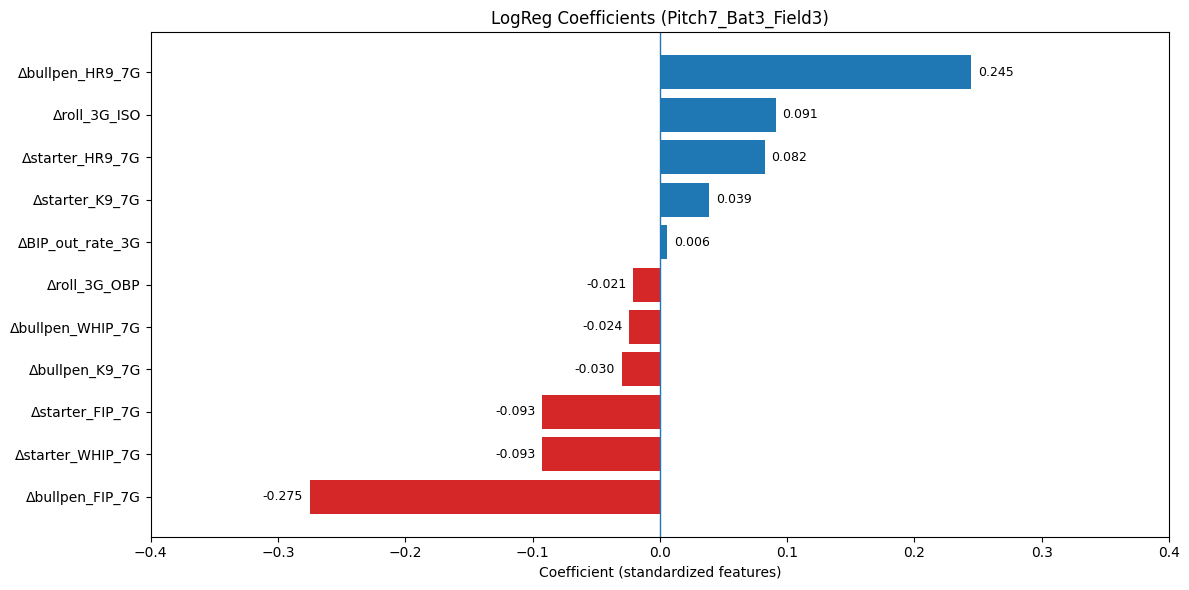

In [10]:
best = results_df.iloc[0]
best_name = best["model"]
best_res = best["fitted"]

Xtr_best = build_feature_set(train_df, windows={"pitch": best["pitch_w"], "bat": best["bat_w"], "field": best["field_w"]})

plot_logreg_coefs(
    best_res["model"],
    feature_names=Xtr_best.columns,
    title=f"LogReg Coefficients ({best_name})",
    xlim=(-0.4, 0.4),
)

### Grid Search

In [11]:
# Time-aware CV
tscv = TimeSeriesSplit(n_splits=5)

# Pipeline: scaling + logistic regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

In [12]:
# Hyperparameter grid
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

In [13]:
# Store final results
tuned_results = []

# Optional: store full fitted objects if you want to inspect later
tuned_models = {}

for cfg in combos:
    name = cfg["name"]
    win_map = cfg["windows"]

    # Build train/test feature sets for this combo
    X_train_combo = build_feature_set(train_df, windows=win_map)
    X_test_combo = build_feature_set(test_df, windows=win_map)

    print("\n" + "=" * 80)
    print(f"TUNING MODEL: {name} | windows={win_map} | n_features={X_train_combo.shape[1]}")
    print("=" * 80)

    # Grid search on training data only
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train_combo, y_train)

    # Best tuned model
    best_model = grid.best_estimator_

    # Evaluate on test set
    y_pred = best_model.predict(X_test_combo)
    y_proba = best_model.predict_proba(X_test_combo)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print("Best params:", grid.best_params_)
    print("Best CV ROC AUC:", grid.best_score_)
    print("Test Accuracy:", acc)
    print("Test ROC AUC:", auc)
    print("Test Log Loss:", ll)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    tuned_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "n_features": X_train_combo.shape[1],
        "best_C": grid.best_params_["model__C"],
        "best_penalty": grid.best_params_["model__penalty"],
        "best_class_weight": grid.best_params_["model__class_weight"],
        "cv_roc_auc": grid.best_score_,
        "test_accuracy": acc,
        "test_roc_auc": auc,
        "test_log_loss": ll
    })

    tuned_models[name] = {
        "grid": grid,
        "best_model": best_model,
        "X_train_columns": X_train_combo.columns
    }

# Final comparison table
tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

tuned_results_df


TUNING MODEL: All_3G | windows={'pitch': '3G', 'bat': '3G', 'field': '3G'} | n_features=11
Best params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC AUC: 0.5497216132053554
Test Accuracy: 0.5530864197530864
Test ROC AUC: 0.5494240856989414
Test Log Loss: 0.6876349530226719

Confusion Matrix:
 [[ 332  779]
 [ 307 1012]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.30      0.38      1111
           1       0.57      0.77      0.65      1319

    accuracy                           0.55      2430
   macro avg       0.54      0.53      0.52      2430
weighted avg       0.54      0.55      0.53      2430


TUNING MODEL: Pitch7_Bat3_Field3 | windows={'pitch': '7G', 'bat': '3G', 'field': '3G'} | n_features=11
Best params: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV ROC AUC: 0.5591612526560652
Test A

,model,pitch_w,bat_w,field_w,n_features,best_C,best_penalty,best_class_weight,cv_roc_auc,test_accuracy,test_roc_auc,test_log_loss
4,All_7G,7G,7G,7G,11,0.001,l2,None,0.562566,0.546914,0.561737,0.686643
2,Pitch7_Bat7_Field3,7G,7G,3G,11,0.010,l2,None,0.564319,0.551440,0.558599,0.686654
3,Pitch3_Bat7_Field7,3G,7G,7G,11,0.001,l2,None,0.553835,0.553086,0.555001,0.687565
1,Pitch7_Bat3_Field3,7G,3G,3G,11,1.000,l1,None,0.559161,0.546502,0.554769,0.686777
0,All_3G,3G,3G,3G,11,0.100,l1,None,0.549722,0.553086,0.549424,0.687635


#### Hyperparameter Tuning Results

After evaluating several rolling-window feature configurations using baseline logistic regression models, hyperparameter tuning was performed using grid search with time-aware cross-validation. The tuning process explored different regularization strengths (C), penalty types (L1 and L2), and class weighting schemes.

Among the tuned models, the configuration using **7-game rolling windows for pitching, batting, and fielding features** produced the best performance on the held-out 2025 test set. This model achieved the **highest ROC-AUC (0.5617)** and the **lowest log loss (0.6866)** among all tested combinations.

Interestingly, the tuned model selected **strong L2 regularization (C = 0.001)**, which suggests that aggressive coefficient shrinkage helps stabilize the model and reduce overfitting. Under this stronger regularization, the smoother 7-game rolling statistics appear to provide more reliable predictive signal than the noisier 3-game windows.

Overall, these results indicate that slightly longer performance windows combined with strong regularization provide the most stable and predictive representation of team performance for logistic regression in this dataset.

## Random Forest

In [14]:
def fit_eval_rf(
    X_train,
    y_train,
    X_test,
    y_test,
    *,
    n_estimators: int = 300,
    max_depth=None,
    min_samples_split: int = 2,
    min_samples_leaf: int = 1,
    max_features="sqrt",
    class_weight=None,
    random_state: int = 42,
) -> dict:
    """
    Fit and evaluate a baseline Random Forest classifier.
    Returns metrics + fitted model.
    """

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print("Log Loss:", ll)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    return {
        "accuracy": acc,
        "roc_auc": auc,
        "log_loss": ll,
        "confusion_matrix": cm,
        "classification_report": report,
        "model": rf_model
    }

In [15]:
rf_results = []

for cfg in combos:
    name = cfg["name"]
    win_map = cfg["windows"]

    X_train_combo = build_feature_set(train_df, windows=win_map)
    X_test_combo = build_feature_set(test_df, windows=win_map)

    print("\n" + "="*70)
    print(f"RANDOM FOREST BASELINE: {name} | windows={win_map} | n_features={X_train_combo.shape[1]}")
    print("="*70)

    res = fit_eval_rf(X_train_combo, y_train, X_test_combo, y_test)

    rf_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "n_features": X_train_combo.shape[1],
        "accuracy": res["accuracy"],
        "roc_auc": res["roc_auc"],
        "log_loss": res["log_loss"],
        "fitted": res
    })

rf_results_df = pd.DataFrame(rf_results).sort_values(
    by=["roc_auc", "log_loss"],
    ascending=[False, True]
)

rf_results_df[["model", "pitch_w", "bat_w", "field_w", "n_features", "accuracy", "roc_auc", "log_loss"]]


RANDOM FOREST BASELINE: All_3G | windows={'pitch': '3G', 'bat': '3G', 'field': '3G'} | n_features=11
Accuracy: 0.5349794238683128
ROC AUC: 0.5288728266306539
Log Loss: 0.6952649687066316

Confusion Matrix:
 [[468 643]
 [487 832]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.42      0.45      1111
           1       0.56      0.63      0.60      1319

    accuracy                           0.53      2430
   macro avg       0.53      0.53      0.52      2430
weighted avg       0.53      0.53      0.53      2430


RANDOM FOREST BASELINE: Pitch7_Bat3_Field3 | windows={'pitch': '7G', 'bat': '3G', 'field': '3G'} | n_features=11
Accuracy: 0.525514403292181
ROC AUC: 0.5303809380179868
Log Loss: 0.6954229704311751

Confusion Matrix:
 [[466 645]
 [508 811]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.42      0.45      1111
           1       0.56      0.61      0.

,model,pitch_w,bat_w,field_w,n_features,accuracy,roc_auc,log_loss
2,Pitch7_Bat7_Field3,7G,7G,3G,11,0.532922,0.544011,0.693504
4,All_7G,7G,7G,7G,11,0.534979,0.540045,0.694389
1,Pitch7_Bat3_Field3,7G,3G,3G,11,0.525514,0.530381,0.695423
3,Pitch3_Bat7_Field7,3G,7G,7G,11,0.530864,0.529824,0.696281
0,All_3G,3G,3G,3G,11,0.534979,0.528873,0.695265


### Analysis

Logistic regression outperformed the Random Forest classifier across all feature combinations. This suggests that the relationship between the engineered team performance features and game outcomes is largely linear. Since the features represent differences in interpretable sabermetric statistics (e.g., FIP, WHIP, OBP), their effects on win probability are expected to be monotonic and approximately linear, which logistic regression captures effectively.

In [16]:
def plot_rf_importance(
    model,
    feature_names,
    *,
    title: str = "Random Forest Feature Importance",
    decimals: int = 3
):
    """
    Plot Random Forest feature importances with labels.
    """
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    
    plt.figure(figsize=(12, max(6, 0.35 * len(importances))))
    plt.barh(importances.index, importances.values)
    plt.title(title)
    plt.xlabel("Importance")

    for y, v in enumerate(importances.values):
        plt.text(v + 0.001, y, f"{v:.{decimals}f}", va="center", ha="left", fontsize=9)

    plt.tight_layout()
    plt.show()

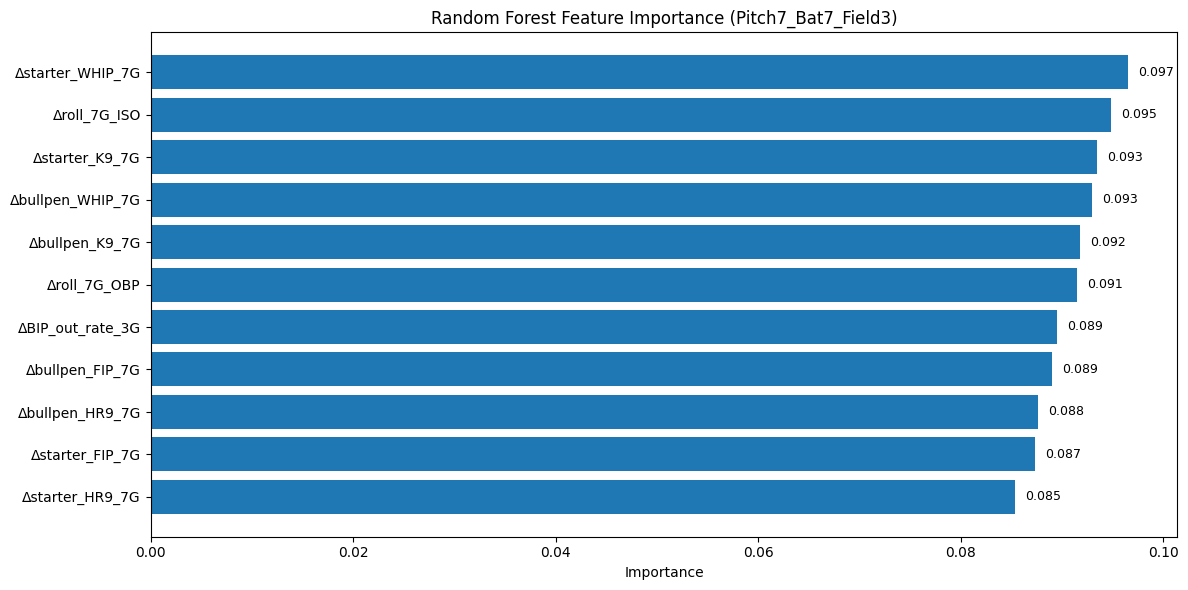

In [17]:
best = rf_results_df.iloc[0]
best_name = best["model"]
best_res = best["fitted"]

Xtr_best = build_feature_set(
    train_df,
    windows={
        "pitch": best["pitch_w"],
        "bat": best["bat_w"],
        "field": best["field_w"]
    }
)

plot_rf_importance(
    best_res["model"],
    feature_names=Xtr_best.columns,
    title=f"Random Forest Feature Importance ({best_name})"
)

### GridSearch

In [ ]:
'''
param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

'''


In [23]:
# Hyperparameter grid
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]
}

rf_tuned_results = []

pbar = tqdm(combos, desc="Tuning RF combos")

for cfg in pbar:
    name = cfg["name"]
    win_map = cfg["windows"]
    pbar.set_postfix(model=name)

    X_train_combo = build_feature_set(train_df, windows=win_map)
    X_test_combo = build_feature_set(test_df, windows=win_map)

    print("\n" + "=" * 80)
    print(f"TUNING RANDOM FOREST: {name} | windows={win_map} | n_features={X_train_combo.shape[1]}")
    print("=" * 80)

    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    grid_rf = GridSearchCV(
        estimator=rf,
        param_grid=param_grid_rf,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
        verbose=2
    )

    grid_rf.fit(X_train_combo, y_train)

    best_model = grid_rf.best_estimator_

    y_pred = best_model.predict(X_test_combo)
    y_proba = best_model.predict_proba(X_test_combo)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print("Best params:", grid_rf.best_params_)
    print("Best CV ROC AUC:", grid_rf.best_score_)
    print("Test Accuracy:", acc)
    print("Test ROC AUC:", auc)
    print("Test Log Loss:", ll)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", report)

    rf_tuned_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "n_features": X_train_combo.shape[1],
        "best_n_estimators": grid_rf.best_params_["n_estimators"],
        "best_max_depth": grid_rf.best_params_["max_depth"],
        "best_min_samples_split": grid_rf.best_params_["min_samples_split"],
        "best_min_samples_leaf": grid_rf.best_params_["min_samples_leaf"],
        "best_max_features": grid_rf.best_params_["max_features"],
        "best_class_weight": grid_rf.best_params_["class_weight"],
        "cv_roc_auc": grid_rf.best_score_,
        "test_accuracy": acc,
        "test_roc_auc": auc,
        "test_log_loss": ll,
        "fitted": {
            "grid": grid_rf,
            "model": best_model
        }
    })

rf_tuned_results_df = pd.DataFrame(rf_tuned_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

rf_tuned_results_df

Tuning RF combos:   0%|          | 0/5 [00:00<?, ?it/s]


TUNING RANDOM FOREST: All_3G | windows={'pitch': '3G', 'bat': '3G', 'field': '3G'} | n_features=11
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC AUC: 0.5463547334490502
Test Accuracy: 0.5300411522633744
Test ROC AUC: 0.5426300780191742
Test Log Loss: 0.6901316868310967

Confusion Matrix:
 [[610 501]
 [641 678]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.55      0.52      1111
           1       0.58      0.51      0.54      1319

    accuracy                           0.53      2430
   macro avg       0.53      0.53      0.53      2430
weighted avg       0.54      0.53      0.53      2430


TUNING RANDOM FOREST: Pitch7_Bat3_Field3 | windows={'pitch': '7G', 'bat': '3G', 'field': '3G'} | n_features=11
Fitting 5 folds for each of 48 candidates, t

,model,pitch_w,bat_w,field_w,n_features,best_n_estimators,best_max_depth,best_min_samples_split,best_min_samples_leaf,best_max_features,best_class_weight,cv_roc_auc,test_accuracy,test_roc_auc,test_log_loss,fitted
1,Pitch7_Bat3_Field3,7G,3G,3G,11,200,5,2,1,sqrt,None,0.553935,0.549794,0.554178,0.685003,{'grid': GridSearchCV(cv=TimeSeriesSplit(gap=0...
4,All_7G,7G,7G,7G,11,200,5,10,4,sqrt,None,0.559904,0.546502,0.552464,0.685585,{'grid': GridSearchCV(cv=TimeSeriesSplit(gap=0...
2,Pitch7_Bat7_Field3,7G,7G,3G,11,200,5,10,1,sqrt,None,0.560334,0.544856,0.552082,0.685752,{'grid': GridSearchCV(cv=TimeSeriesSplit(gap=0...
3,Pitch3_Bat7_Field7,3G,7G,7G,11,200,5,10,1,sqrt,balanced,0.552899,0.528807,0.543658,0.690259,{'grid': GridSearchCV(cv=TimeSeriesSplit(gap=0...
0,All_3G,3G,3G,3G,11,200,5,2,1,sqrt,balanced,0.546355,0.530041,0.542630,0.690132,{'grid': GridSearchCV(cv=TimeSeriesSplit(gap=0...


[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   2.1s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   2.1s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.0s
[CV] END class_weight=None, 

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   1.2s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   1.1s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   1.2s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.9s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=400; total time=   1.1s
[CV] END class_weight=None, ma

...

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.8s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   2.3s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   3.0s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   1.4s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.6s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.3s
[CV] END class_weight=None,

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.4s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.2s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   3.0s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=400; total time=   1.8s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.3s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   2.3s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END class_weight=None,

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   1.6s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.6s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   2.1s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=400; total time=   2.4s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   5.2s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   4.4s
[CV] END class_weight=None, ma

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   1.9s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   1.5s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.4s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   1.4s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=400; total time=   3.3s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   2.1s
[CV] END class_weight=None, 

[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   2.6s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.5s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   0.9s
[CV] END class_weight=None, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=400; total time=   2.0s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   3.0s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=400; total time=   4.0s
[CV] END class_weight=None, m

#### Tuned Random Forest Results

A tuned Random Forest classifier was evaluated across the same rolling-window feature combinations used in the logistic regression analysis. The best-performing Random Forest model used **7-game pitching**, **3-game batting**, and **3-game fielding** features (`Pitch7_Bat3_Field3`). This model achieved a **test ROC-AUC of 0.5542**, a **log loss of 0.6850**, and an **accuracy of 0.5498**.

Although the tuned Random Forest slightly improved over its untuned baseline, it did **not outperform the tuned logistic regression model** on the primary evaluation metric, ROC-AUC. The tuned logistic regression achieved a higher test ROC-AUC of **0.5617**, indicating better ranking performance for predicted game outcomes.

These results suggest that the relationship between the engineered matchup features and game outcomes is largely captured by a relatively simple linear model. Because the features are already highly structured and interpretable, the additional flexibility of Random Forest does not appear to provide a substantial advantage in this setting. As a result, the tuned logistic regression model remains the preferred final model.

## XGBoost

### Baseline Model

In [7]:
def fit_eval_xgb(X_train, y_train, X_test, y_test):

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)

    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print("Log Loss:", ll)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return {
        "model": model,
        "accuracy": acc,
        "roc_auc": auc,
        "log_loss": ll
    }

In [9]:
xgb_results = []

for cfg in combos:

    name = cfg["name"]
    win_map = cfg["windows"]

    X_train_combo = build_feature_set(train_df, windows=win_map)
    X_test_combo = build_feature_set(test_df, windows=win_map)

    print("\n" + "="*70)
    print(f"XGBOOST BASELINE: {name} | windows={win_map}")
    print("="*70)

    res = fit_eval_xgb(X_train_combo, y_train, X_test_combo, y_test)

    xgb_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "accuracy": res["accuracy"],
        "roc_auc": res["roc_auc"],
        "log_loss": res["log_loss"],
        "fitted": res
    })

xgb_results_df = pd.DataFrame(xgb_results).sort_values(
    by=["roc_auc","log_loss"],
    ascending=[False,True]
)

xgb_results_df


XGBOOST BASELINE: All_3G | windows={'pitch': '3G', 'bat': '3G', 'field': '3G'}
Accuracy: 0.5242798353909465
ROC AUC: 0.5255147197813034
Log Loss: 0.6962824409068605

Confusion Matrix:
 [[447 664]
 [492 827]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.40      0.44      1111
           1       0.55      0.63      0.59      1319

    accuracy                           0.52      2430
   macro avg       0.52      0.51      0.51      2430
weighted avg       0.52      0.52      0.52      2430


XGBOOST BASELINE: Pitch7_Bat3_Field3 | windows={'pitch': '7G', 'bat': '3G', 'field': '3G'}
Accuracy: 0.5378600823045268
ROC AUC: 0.546620431565522
Log Loss: 0.6900466650642435

Confusion Matrix:
 [[448 663]
 [460 859]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.40      0.44      1111
           1       0.56      0.65      0.60      1319

    accuracy                  

,model,pitch_w,bat_w,field_w,accuracy,roc_auc,log_loss,fitted
1,Pitch7_Bat3_Field3,7G,3G,3G,0.537860,0.546620,0.690047,"{'model': XGBClassifier(base_score=None, boost..."
4,All_7G,7G,7G,7G,0.533333,0.542716,0.693086,"{'model': XGBClassifier(base_score=None, boost..."
2,Pitch7_Bat7_Field3,7G,7G,3G,0.530864,0.539693,0.693093,"{'model': XGBClassifier(base_score=None, boost..."
3,Pitch3_Bat7_Field7,3G,7G,7G,0.524280,0.526510,0.697374,"{'model': XGBClassifier(base_score=None, boost..."
0,All_3G,3G,3G,3G,0.524280,0.525515,0.696282,"{'model': XGBClassifier(base_score=None, boost..."


### Baseline XGBoost Results

A baseline XGBoost classifier was evaluated across the same rolling-window feature combinations used in the logistic regression and random forest analyses. The best-performing XGBoost configuration used **7-game pitching**, **3-game batting**, and **3-game fielding** features (`Pitch7_Bat3_Field3`), achieving a **test ROC-AUC of 0.5466**.

However, baseline XGBoost did not outperform either the tuned logistic regression model or the tuned random forest model. This suggests that the relationship between the engineered matchup features and game outcomes is captured reasonably well by simpler model structures, particularly logistic regression. Because the features are already highly structured and interpretable, the additional nonlinear flexibility of XGBoost does not appear to provide a substantial advantage in this baseline setting.

### XGB Baseline Feature Importance

In [10]:
def plot_xgb_importance(
    model,
    feature_names,
    *,
    title: str = "XGBoost Feature Importance",
    decimals: int = 3
):
    """
    Plot XGBoost feature importances with labels.
    """
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    
    plt.figure(figsize=(12, max(6, 0.35 * len(importances))))
    plt.barh(importances.index, importances.values)
    plt.title(title)
    plt.xlabel("Importance")

    for y, v in enumerate(importances.values):
        plt.text(v + 0.001, y, f"{v:.{decimals}f}", va="center", ha="left", fontsize=9)

    plt.tight_layout()
    plt.show()

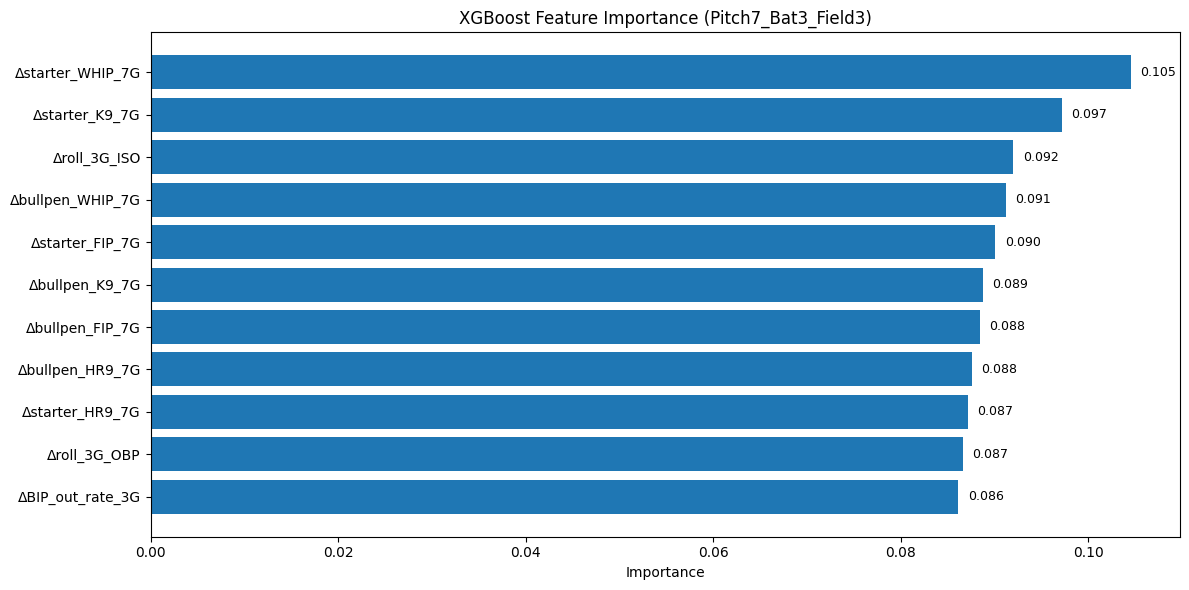

In [11]:
best = xgb_results_df.iloc[0]
best_name = best["model"]
best_res = best["fitted"]

Xtr_best = build_feature_set(
    train_df,
    windows={
        "pitch": best["pitch_w"],
        "bat": best["bat_w"],
        "field": best["field_w"]
    }
)

plot_xgb_importance(
    model=best_res["model"],
    feature_names=Xtr_best.columns,
    title=f"XGBoost Feature Importance ({best_name})"
)

### GridSearch

In [12]:
# Best baseline XGBoost combo
best_xgb_combo = {
    "name": "Pitch7_Bat3_Field3",
    "windows": {"pitch": "7G", "bat": "3G", "field": "3G"}
}

X_train_xgb = build_feature_set(train_df, windows=best_xgb_combo["windows"])
X_test_xgb = build_feature_set(test_df, windows=best_xgb_combo["windows"])

tscv = TimeSeriesSplit(n_splits=3)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=2
)

grid_xgb.fit(X_train_xgb, y_train)

best_xgb = grid_xgb.best_estimator_

y_pred = best_xgb.predict(X_test_xgb)
y_proba = best_xgb.predict_proba(X_test_xgb)[:, 1]

print("Best params:", grid_xgb.best_params_)
print("Best CV ROC AUC:", grid_xgb.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Test Log Loss:", log_loss(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC AUC: 0.5461972788489923
Test Accuracy: 0.5440329218106996
Test ROC AUC: 0.552618756947719
Test Log Loss: 0.6858217731385723

Confusion Matrix:
 [[432 679]
 [429 890]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.39      0.44      1111
           1       0.57      0.67      0.62      1319

    accuracy                           0.54      2430
   macro avg       0.53      0.53      0.53      2430
weighted avg       0.54      0.54      0.53      2430



### XGBoost Results

A tuned XGBoost classifier was evaluated using the best-performing rolling window configuration from the baseline experiments. The optimized model achieved a test ROC-AUC of **0.5526**, a log loss of **0.6858**, and an accuracy of **0.5440**.

While XGBoost slightly improved over the untuned baseline model, it did not outperform the tuned logistic regression model, which achieved a higher ROC-AUC of **0.5617**. The results suggest that the relationship between the engineered matchup features and game outcomes is captured effectively by a relatively simple linear model. Because the features already represent meaningful performance differentials between teams, the additional nonlinear flexibility of gradient boosting does not provide a substantial improvement in predictive performance in this setting.

Consequently, the **tuned logistic regression model remains the preferred final model** for predicting game outcomes.